In [1]:
! pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   --- ------------------------------------ 8.4/101.7 MB 47.2 MB/s eta 0:00:02
   -------- ------------------------------- 21.5/101.7 MB 54.3 MB/s eta 0:00:02
   -------------- ------------------------- 35.9/101.7 MB 60.0 MB/s eta 0:00:02
   ------------------- -------------------- 50.6/101.7 MB 63.2 MB/s eta 0:00:01
   ----------------------- ---------------- 60.6/101.7 MB 60.3 MB/s eta 0:00:01
   --------------------------- ------------ 68.9/101.7 MB 56.3 MB/s eta 0:00:01
   ------------------------------ --------- 77.1/101.7 MB 54.0 MB/s eta 0:00:01
   --------------------------------- ------ 84.1/101.7 MB 51.6 MB/s eta 0:00:01
   ----------------------------------- ---- 89.4/101.7 MB 48.3 MB/s eta 0:00:01
   ------------------------------------- -- 94.4/101.7 MB 46.0 MB/s eta 0:00:01
   --------------------------------------  100.7/101.7 MB 44.3 MB/s eta 0:00:01
   --------------------------------------  101.4/1

1. 위스콘신 유방암 데이터셋 컬럼 설명

이 데이터는 종양의 세포 핵(nucleus) 모양을 여러 지표로 표현한 것입니다.
각 feature는 다음 10개의 기본 값에 대해,

mean : 평균값

error : 표준오차(측정값의 변동성)

worst : 가장 안 좋은(최대) 값 근처의 평균

을 저장해놨다고 보면 됩니다.

| 컬럼명                        | 의미                           | 쉽게 설명                               |
| -------------------------- | ---------------------------- | ----------------------------------- |
| **mean radius**            | 세포 핵 반지름의 평균                 | 종양 이미지를 봤을 때 **세포 핵 크기의 평균 반경**     |
| **mean texture**           | 그레이스케일 값의 표준편차(질감) 평균        | 밝기 다양성 → **표면 질감의 거칠기/불균일성의 평균**    |
| **mean perimeter**         | 둘레 길이 평균                     | 세포 핵의 **경계 선 길이 평균**                |
| **mean area**              | 면적 평균                        | 세포 핵이 차지하는 **면적의 평균 크기**            |
| **mean smoothness**        | 반지름 길이 변화 정도 평균              | 경계가 **얼마나 매끈한지(=거칠지 않은지)** 평균       |
| **mean compactness**       | (perimeter² / area - 1.0) 평균 | **얼마나 조밀한지/둥근지**를 나타내는 값            |
| **mean concavity**         | 오목한 부분의 심각도 평균               | 경계가 **안쪽으로 파인 정도의 평균**              |
| **mean concave points**    | 오목한 부분의 개수 평균                | 경계가 **안쪽으로 꺾인 지점의 개수 평균**           |
| **mean symmetry**          | 대칭성 평균                       | 세포 모양이 **얼마나 좌우로 대칭적인지** 평균         |
| **mean fractal dimension** | 프랙탈 차원 평균                    | 경계의 복잡도, **“해안선 길이”처럼 복잡할수록 커지는 값** |


| 컬럼명                         | 의미              |
| --------------------------- | --------------- |
| **radius error**            | 반지름 값의 표준오차     |
| **texture error**           | 질감 값의 표준오차      |
| **perimeter error**         | 둘레 값의 표준오차      |
| **area error**              | 면적 값의 표준오차      |
| **smoothness error**        | 매끄러움 값의 표준오차    |
| **compactness error**       | 조밀도 값의 표준오차     |
| **concavity error**         | 오목함 심각도 값의 표준오차 |
| **concave points error**    | 오목 지점 개수의 표준오차  |
| **symmetry error**          | 대칭성 값의 표준오차     |
| **fractal dimension error** | 프랙탈 차원 값의 표준오차  |

| 컬럼명                         | 의미                                |
| --------------------------- | --------------------------------- |
| **worst radius**            | 가장 큰 반지름 값들에서 뽑은 평균 (최악에 가까운 반지름) |
| **worst texture**           | 가장 심한 질감(표준편차) 값들의 평균             |
| **worst perimeter**         | 가장 큰 둘레 값들의 평균                    |
| **worst area**              | 가장 큰 면적 값들의 평균                    |
| **worst smoothness**        | 가장 덜 매끄러운 상태의 평균                  |
| **worst compactness**       | 가장 조밀한(또는 비정상적인) 상태의 평균           |
| **worst concavity**         | 가장 심하게 오목한 상태의 평균                 |
| **worst concave points**    | 가장 오목한 지점이 많은 상태의 평균              |
| **worst symmetry**          | 가장 비대칭적인 상태의 평균                   |
| **worst fractal dimension** | 가장 복잡한 경계 상태의 평균                  |


➡ 요약하면:

mean 계열: 종양 전체의 전반적인 특징

error 계열: 값의 변동성 (안정적인지, 들쭉날쭉한지)

worst 계열: 가장 안 좋은 쪽 특성 (악성 판별에 특히 중요)

In [2]:
import xgboost
print(xgboost.__version__)

3.2.0


In [16]:
import xgboost as xgb                                       
from xgboost import plot_importance                         
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer            # 위스콘신 유방암 데이터셋을 불러오기
from sklearn.model_selection import train_test_split      

from sklearn.metrics import confusion_matrix, accuracy_score    
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

import warnings                                            
warnings.filterwarnings('ignore')

In [4]:
# 유방암 데이터셋을 불러오기
dataset = load_breast_cancer()                                           # 유방암 데이터셋 가져오기
X_features = dataset.data                                                # 가져온 데이터셋에서 입력 변수(feature)만 설정
y_label = dataset.target                                                 # 정답 레이블(target : 악성/양성)을 y_label 변수에 저장

cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)    # 데이터를 pandas dataframe 구조로 변환해서 컬럼명을 부여

cancer_df['target'] = y_label                                               # dataframe의 마지막 열에 target 컬럼값을 추가해서 y_label 값 넣어줌

cancer_df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [5]:
# 타겟의 0과1이 각각 몇 개 있는지 출력하여 데이터 분포 확인 (0:악성 / 1:양성)
cancer_df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [6]:
X_features = cancer_df.iloc[:, :-1]        # feature 컬럼만 선택하기 위해 마지막 target 컬럼을 제외한 모든 컬럼값이 입력 데이터로 사용
y_label = cancer_df.iloc[:, -1]            # 마지막 컬럼 target만 선택해서 label 데이터로 사용

In [7]:
X_features

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [8]:
y_label

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64

In [9]:
# 학습 데이터 분할 (학습 : 80%, 테스트 : 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156)

# 전체 데이터에서 학습 90%, 테스트 10% 비율로 분리하고 모델 튜닝시 활용
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)


(455, 30) (114, 30)
(409, 30) (46, 30)


In [10]:
# xgboost가 계산을 최적화하기 위해 사용하는 DMatrix 구조로 학습 데이터를 변환
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [11]:
# 모델 학습에 필요한 하이퍼파라메터 설정
params = {
    'max_depth' : 3,                    # 트리의 깊이를 3개로 제한해서 과적합을 방지
    'eta' : 0.5,                        # learning rate를 설정하여 한번의 학습 단계에서 조정되는 크기 설정
    'objective' : 'binary:logistic',    # 이진 분류 문제이므로 로지스틱 함수를 사용해서 확률로 예측
    'eval_metric' : 'logloss'           # 평가 지표 : 로그손실(logloss)을 사용
}

num_rounds = 400                        # 최대 boosting 반복 횟수 정의

In [13]:
# 모델 설정

eval_list = [(dtr, 'train'), (dval, 'eval')]

xgb_model = xgb.train(
    params=params,
    dtrain=dtr,
    num_boost_round=num_rounds,
    early_stopping_rounds=50,              # 학습시, 모델 성능이 개선되었거나, 계속 개선되지 않으면 학습을 조기 종료
    evals=eval_list
)

[0]	train-logloss:0.33637	eval-logloss:0.44579
[1]	train-logloss:0.20512	eval-logloss:0.35638
[2]	train-logloss:0.13638	eval-logloss:0.30729
[3]	train-logloss:0.09867	eval-logloss:0.27589
[4]	train-logloss:0.07345	eval-logloss:0.27413
[5]	train-logloss:0.05879	eval-logloss:0.27065
[6]	train-logloss:0.04771	eval-logloss:0.26873
[7]	train-logloss:0.03821	eval-logloss:0.26627
[8]	train-logloss:0.03192	eval-logloss:0.27051
[9]	train-logloss:0.02761	eval-logloss:0.27630
[10]	train-logloss:0.02324	eval-logloss:0.27361
[11]	train-logloss:0.02011	eval-logloss:0.26487
[12]	train-logloss:0.01791	eval-logloss:0.27232
[13]	train-logloss:0.01598	eval-logloss:0.26959
[14]	train-logloss:0.01456	eval-logloss:0.25917
[15]	train-logloss:0.01352	eval-logloss:0.26260
[16]	train-logloss:0.01250	eval-logloss:0.25960
[17]	train-logloss:0.01143	eval-logloss:0.26172
[18]	train-logloss:0.01086	eval-logloss:0.26168
[19]	train-logloss:0.01029	eval-logloss:0.26545
[20]	train-logloss:0.00978	eval-logloss:0.26266
[2

In [14]:
# 테스트 데이터셋에 대해 모델이 예측한 확률값
pred_probs = xgb_model.predict(dtest)

# 예측한 확률값 중에서 처음 10개만 출력하여 예측 결과값 확인
print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시')
print(np.round(pred_probs[:10], 3))

# 예측된 확률값이 0.5보다 크면 양성(1), 그렇지 않으면 악성(0)으로 판단
preds = [1 if x > 0.5 else 0 for x in pred_probs]

print('예측값 10개만 표시 : ', preds[:10])


predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시
[0.977 0.005 0.746 0.004 0.995 1.    1.    1.    1.    0.   ]
예측값 10개만 표시 :  [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [17]:
# 모델 성능 평가

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)

    print('오차행렬')
    print(confusion)

    print('정확도 : {0:.4f}, 정밀도 : {1:.4f}, 재현율 : {2:.4f}, F1 : {3:.4f}, AUC : {4:.4f}'.format(
    accuracy, precision, recall, f1, roc_auc))

get_clf_eval(y_test, preds, pred_probs)

오차행렬
[[34  3]
 [ 2 75]]
정확도 : 0.9561, 정밀도 : 0.9615, 재현율 : 0.9740, F1 : 0.9677, AUC : 0.9958


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

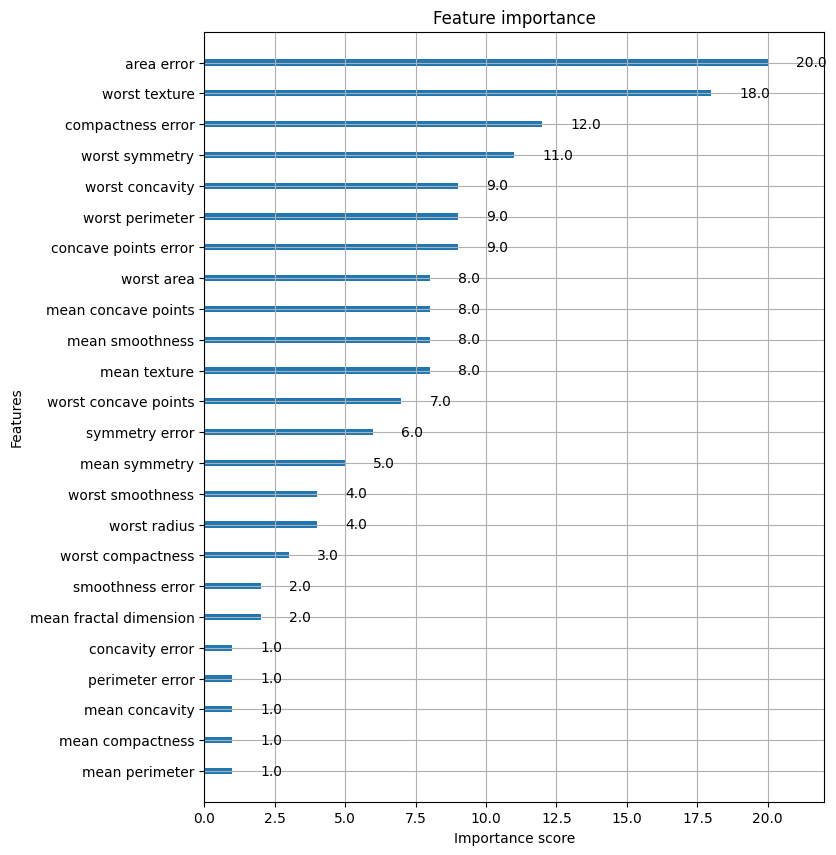

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt

# feature importance 시각화 (모델이 예측한 y에 영향을 준 x 인자의 중요도 계산)
fig, ax = plt.subplots(figsize=(8,10))
plot_importance(xgb_model, ax=ax)